In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

In [2]:
# Load cleaned dataset

df = pd.read_csv("../processed/cleaned_youtube_data.csv")

df.head()

,video_duration_min,avg_view_duration_sec,avg_view_percentage,subscribers_gained,traffic_source,ctr_percentage,impressions,likes,comments,shares,total_watch_time_hours,content_category
0,45.55,2422,88.62,564,Shorts Feed,28.70,1975899,88186,1055,63,1329340.94,Sports
1,59.12,562,15.84,523,Notifications,25.67,1552915,69884,5883,131,242427.29,Vlog
2,40.06,2369,98.56,628,External,10.13,90886,37931,3746,2555,59808.04,News
3,42.54,2097,82.16,239,External,25.00,999294,38861,1575,900,582088.76,Education
4,31.40,1424,75.58,138,Shorts Feed,23.49,1656171,57043,3150,1452,655107.64,Sports


In [3]:
X = df[
    [
        "video_duration_min",
        "likes",
        "comments"
    ]
]

y = df["avg_view_percentage"]

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

In [5]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

print("Scaling completed successfully.")

Scaling completed successfully.


In [6]:
# Compare original and scaled values

original = pd.DataFrame(
    X_train.head(),
    columns=X.columns
)

scaled = pd.DataFrame(
    X_train_scaled[:5],
    columns=X.columns
)

print("Original Values")
display(original)

print("\nScaled Values")
display(scaled)

Original Values


,video_duration_min,likes,comments
21753,46.24,26548,751
251,48.89,17401,5195
22941,28.87,31008,233
618,44.32,33104,6180
17090,43.45,34008,4237



Scaled Values


,video_duration_min,likes,comments
0,0.921716,-0.816025,-1.413514
1,1.076866,-1.133465,0.512808
2,-0.095245,-0.661243,-1.638049
3,0.809306,-0.588503,0.939771
4,0.758370,-0.557130,0.097548


In [7]:
scaled_model = LinearRegression()

scaled_model.fit(
    X_train_scaled,
    y_train
)

print("Model trained successfully.")

Model trained successfully.


In [8]:
y_pred = scaled_model.predict(X_test_scaled)

In [9]:
mae = mean_absolute_error(y_test, y_pred)

mse = mean_squared_error(y_test, y_pred)

rmse = np.sqrt(mse)

r2 = r2_score(y_test, y_pred)

print("Mean Absolute Error :", mae)
print("Mean Squared Error :", mse)
print("Root Mean Squared Error :", rmse)
print("R² Score :", r2)

Mean Absolute Error : 24.9431088916824
Mean Squared Error : 828.5917887821859
Root Mean Squared Error : 28.7852703440872
R² Score : -0.00015091458913207845


In [10]:
comparison = pd.DataFrame({
    "Model": [
        "Multiple Linear Regression",
        "Scaled Multiple Linear Regression"
    ],
    "MAE": [
        24.9431088916824,
        mae
    ],
    "RMSE": [
        28.7852703440872,
        rmse
    ],
    "R² Score": [
        -0.00015091458913207845,
        r2
    ]
})

comparison

,Model,MAE,RMSE,R² Score
0,Multiple Linear Regression,24.943109,28.78527,-0.000151
1,Scaled Multiple Linear Regression,24.943109,28.78527,-0.000151


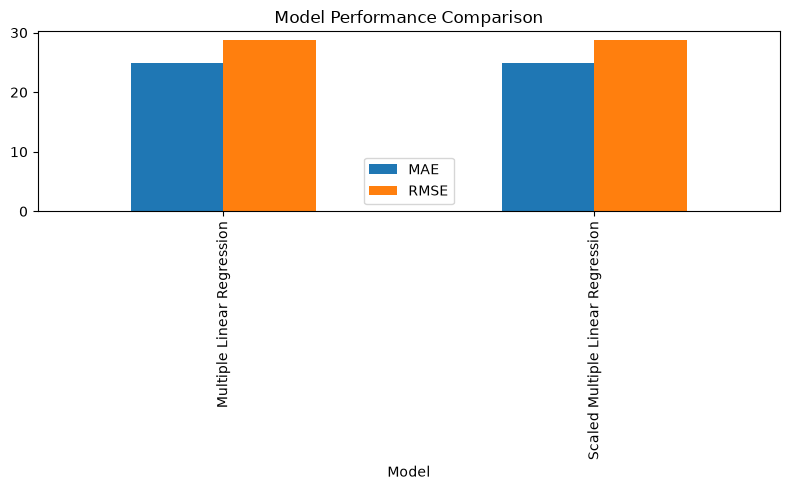

In [11]:
comparison.plot(
    x="Model",
    y=["MAE","RMSE"],
    kind="bar",
    figsize=(8,5)
)

plt.title("Model Performance Comparison")

plt.tight_layout()

plt.savefig(
    "../images/scaling_comparison.png",
    dpi=300
)

plt.show()

# Understanding Underfitting

A model is said to underfit when it is too simple to learn the underlying relationship in the data.

Characteristics:

- High training error
- High testing error
- Poor predictive performance

In this project, the Simple Linear Regression model is an example of underfitting because the selected features contain very little predictive information.

# Understanding Overfitting

Overfitting occurs when a model learns not only the underlying pattern but also the random noise present in the training data.

Characteristics:

- Very low training error
- High testing error
- Poor generalization to new data

Polynomial regression with a very high degree (such as degree 10 or degree 20) may overfit the training data.

In this project, degree 3 was used to provide a balance between flexibility and model complexity.

# Why Didn't Scaling Improve the Model?

Feature scaling changes the range of numerical values but does not create new information.

Since the selected features have almost no relationship with the target variable, scaling cannot improve the predictive performance.

Scaling is most useful for algorithms that depend on distances or gradient-based optimization, such as:

- K-Nearest Neighbors (KNN)
- Support Vector Machines (SVM)
- Logistic Regression
- Neural Networks

For Ordinary Least Squares Linear Regression, scaling generally has little effect on prediction accuracy.

# Final Takeaways

Through this project, the complete machine learning workflow was implemented:

- Data Cleaning
- Exploratory Data Analysis
- Simple Linear Regression
- Multiple Linear Regression
- Polynomial Regression
- Feature Scaling
- Model Evaluation
- Model Serialization

Although the models achieved low predictive performance, the project demonstrates the complete end-to-end process of building and evaluating machine learning regression models.